In [1]:
import pandas as pd

data = pd.read_csv("../data/vegetable_prices.csv")

data.head()

,Datesk,Item_Name,Date,Price
0,20110101,Kashini greens,1/1/2011,NaN
1,20110101,Pineapple juice,1/1/2011,NaN
2,20110101,Thiland Juice,1/1/2011,NaN
3,20110101,Thiland Jelly,1/1/2011,NaN
4,20110101,Orange juice,1/1/2011,NaN


In [2]:
data.head()
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 868965 entries, 0 to 868964
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Datesk     868965 non-null  int64  
 1   Item_Name  861126 non-null  object 
 2   Date       868965 non-null  object 
 3   Price      551948 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 26.5+ MB


,Datesk,Price
count,8.689650e+05,551948.000000
mean,2.014152e+07,51.664567
std,2.062121e+04,68.496674
min,2.011010e+07,0.000000
25%,2.012101e+07,0.000000
50%,2.014073e+07,30.000000
75%,2.016051e+07,67.000000
max,2.018023e+07,863.000000


In [3]:
data.isnull().sum()

Datesk            0
Item_Name      7839
Date              0
Price        317017
dtype: int64

In [6]:
data = data.dropna(subset=['Price'])

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 551948 entries, 296 to 868964
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Datesk     551948 non-null  int64  
 1   Item_Name  551948 non-null  object 
 2   Date       551948 non-null  object 
 3   Price      551948 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 21.1+ MB


In [8]:
data['Date'] = pd.to_datetime(data['Date'])

ValueError: time data "14/03/2011" doesn't match format "%m/%d/%Y", at position 3. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 551948 entries, 296 to 868964
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Datesk     551948 non-null  int64  
 1   Item_Name  551948 non-null  object 
 2   Date       551948 non-null  object 
 3   Price      551948 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 21.1+ MB


In [10]:
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)

ValueError: time data "13-01-2012" doesn't match format "%d/%m/%Y", at position 233. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [11]:
data['Date'] = pd.to_datetime(data['Date'], format='mixed', dayfirst=True)

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 551948 entries, 296 to 868964
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Datesk     551948 non-null  int64         
 1   Item_Name  551948 non-null  object        
 2   Date       551948 non-null  datetime64[ns]
 3   Price      551948 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 21.1+ MB


In [13]:
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month

In [14]:
data.head()

,Datesk,Item_Name,Date,Price,Year,Month
296,20110101,Sponge Gourd,2011-01-01,32.0,2011,1
22311,20110309,Berry Southafrica,2011-03-09,0.0,2011,3
22312,20110309,Baby corn cleaned,2011-03-09,56.0,2011,3
22313,20110309,Baby corn,2011-03-09,14.0,2011,3
22314,20110309,Chillies Bajji yagani,2011-03-09,0.0,2011,3


In [15]:
data = data[data['Price'] > 0]

In [16]:
data.describe()

,Datesk,Date,Price,Year,Month
count,3.956500e+05,395650,395650.000000,395650.000000,395650.000000
mean,2.014374e+07,2014-10-22 08:09:58.055857664,72.074193,2014.307398,6.524868
min,2.011010e+07,2011-01-01 00:00:00,1.000000,2011.000000,1.000000
25%,2.013022e+07,2013-02-18 00:00:00,27.000000,2013.000000,4.000000
50%,2.014111e+07,2014-11-08 00:00:00,45.000000,2014.000000,7.000000
75%,2.016070e+07,2016-07-02 00:00:00,90.000000,2016.000000,10.000000
max,2.018023e+07,2018-02-27 00:00:00,863.000000,2018.000000,12.000000
std,1.999609e+04,NaN,71.233696,2.004257,3.444709


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [18]:
top_items = data.groupby('Item_Name')['Price'].mean().sort_values(ascending=False).head(10)
top_items

Item_Name
Rice Bran 15 lt Tin        798.000000
Ground nut oil 5 lt        562.547619
Sun safal Tin 15 lt        500.000000
Sungold oil 5 lt           421.547619
Sungold oil 5 lt packet    400.000000
Rice Bran 5 lt             392.357143
Cherry kashmir             372.000000
Batani kalu                345.893617
Cucumber Ooty              340.000000
Grapes Red globe           336.689039
Name: Price, dtype: float64

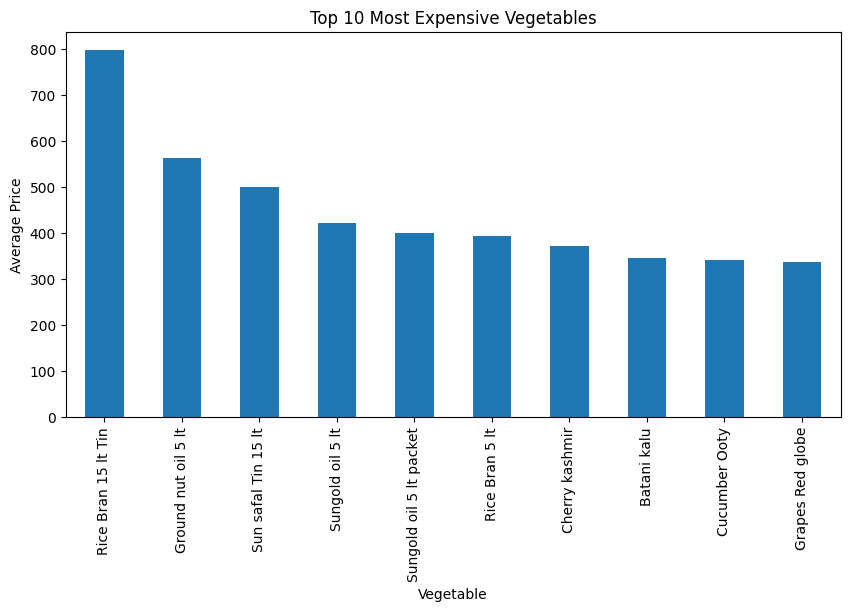

In [19]:
plt.figure(figsize=(10,5))
top_items.plot(kind='bar')

plt.title("Top 10 Most Expensive Vegetables")
plt.xlabel("Vegetable")
plt.ylabel("Average Price")

plt.show()

In [20]:
data[data['Item_Name'].str.contains('Tomato', case=False)]

,Datesk,Item_Name,Date,Price,Year,Month


In [21]:
tomato_data = data[data['Item_Name'].str.contains('Tomato', case=False)]
tomato_data.head()

,Datesk,Item_Name,Date,Price,Year,Month


In [22]:
tomato_data.shape

(0, 6)

In [23]:
data['Item_Name'].unique()

array(['Sponge Gourd', 'Baby corn cleaned', 'Baby corn',
       'Chilakarive green', 'Chakota greens', 'Eggs', 'Arive greens',
       'knol-khol', 'Chikadi kai', 'Garlic cleaned', 'Garlic', 'Ginger',
       'Ground nut Local', 'Double Beans', 'Double Beans seeds',
       'Drumstik', 'Cauliflower per Kg', 'Cauliflower(M)',
       'Mushroom Button', 'Grapes Dry 250gm', 'Grapes Red globe',
       'Lime Local', 'Little gourd', 'Ladys finger', 'Herali kai',
       'Grapes T.S.', 'Avarekai (Field Beans )',
       'Banana cooking R.Banana', 'Jukani', 'Sham gadde',
       'Snake Gourd(S)', 'Snake Gourd', 'Raddish Red', 'Raddish',
       'Sweet Potato(Genasu)', 'Potato(B)', 'Potato(M)', 'Pumpkin Japan',
       'Pumpkin Red', 'Pumpkin Ash', 'Orange malt', 'Grapes Blore blue',
       'Guava Allahabad(Red)', 'Guava', 'Chicco(Sapota)', 'Custerd Apple',
       'Chicco(Sapota) rapined', 'Banana Rasabale', 'Banana Nendra',
       'Banana chandra', 'Banana Yellaki', 'Banana pachabale',
       'Apple Gr

In [24]:
data['Item_Name'].value_counts().head(30)

Item_Name
Amla                       2048
Brinjal (W)                2048
Brinjal (R)                2048
Brinjal Bottle             2048
Pumpkin Ash                2048
Beet Root                  2048
Yam/S.Root                 2048
Jukani                     2048
Sham gadde                 2048
Little gourd               2048
Herali kai                 2048
Banana cooking R.Banana    2048
Mushroom Button            2048
Cauliflower(M)             2048
Coconut (M)                2048
Capsicum Red/Yellow        2048
Raddish                    2048
Sweet Potato(Genasu)       2048
Pumpkin Japan              2048
Pumpkin Red                2048
Chakota greens             2048
Eggs                       2048
knol-khol                  2048
Chikadi kai                2048
Ground nut Local           2048
Molake kalu                2048
Chillies small (C.B.P)     2048
Chillies Green             2048
Coconut (S)                2048
Coconut (OS)               2048
Name: count, dtype: int64

In [25]:
beet_data = data[data['Item_Name'] == 'Beet Root']
beet_data.head()

,Datesk,Item_Name,Date,Price,Year,Month
22621,20110309,Beet Root,2011-03-09,19.0,2011,3
22898,20110310,Beet Root,2011-03-10,19.0,2011,3
24230,20110314,Beet Root,2011-03-14,19.0,2011,3
24911,20110316,Beet Root,2011-03-16,19.0,2011,3
25170,20110317,Beet Root,2011-03-17,19.0,2011,3


In [26]:
beet_data.shape

(2048, 6)

In [27]:
beet_data = beet_data.sort_values(by='Date')

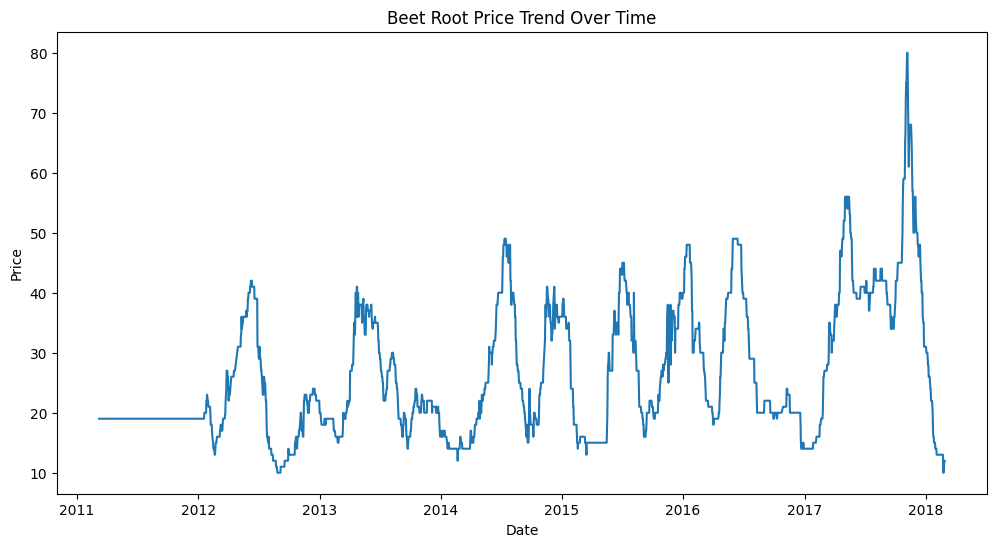

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(beet_data['Date'], beet_data['Price'])

plt.title("Beet Root Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

In [29]:
X = beet_data[['Year','Month']]
y = beet_data['Price']

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [32]:
predictions = model.predict(X_test)

predictions[:10]

array([27.72149714, 23.69767261, 19.4008477 , 32.14549098, 32.29132245,
       25.9190008 , 21.20334403, 24.66250524, 23.970673  , 30.7618265 ])

In [33]:
from sklearn.metrics import mean_absolute_error

error = mean_absolute_error(y_test, predictions)

print("Average Prediction Error:", error)

Average Prediction Error: 7.870204778012949


In [34]:
def predict_price(year, month):
    prediction = model.predict([[year, month]])
    return prediction[0]


In [35]:
predict_price(2025, 6)

C:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(52.937783318864604)

In [36]:
import pandas as pd

def predict_price(year, month):
    input_data = pd.DataFrame({
        'Year':[year],
        'Month':[month]
    })
    
    prediction = model.predict(input_data)
    
    return prediction[0]

In [37]:
predict_price(2025,6)

np.float64(52.937783318864604)